# Exercise 01:

Show that $\hat{\sigma}^2 \equiv \frac{{ \rm RSS}(\hat{\beta})}{N - p}$ is an unbiased estimator of $\sigma^2$, provided that $\varepsilon_i$ are unknown iid $\mathcal{N}(0, \ \sigma^2)$

Considering the relation $Y = X\beta + \varepsilon$ and $i$ runs over $N$ data points each has $p$ number of features.

We consider the linear model:

$$
Y = X\beta + \varepsilon, \quad \varepsilon \sim N(0, \sigma^2 I_N)
$$

where:

- $Y$ is the $N \times 1$ vector of observed responses  
- $X$ is the $N \times p$ design matrix  
- $\beta$ is the $p \times 1$ vector of unknown coefficients  
- $\varepsilon$ is the error vector with mean $0$ and variance $\sigma^2$  

The residuals are defined as:

$$
e = Y - X\hat\beta
$$

with $\hat\beta = (X^\top X)^{-1} X^\top Y$ being the ordinary least squares estimator. The **residual sum of squares (RSS)** is:

$$
\mathrm{RSS} = e^\top e = (Y - X\hat\beta)^\top (Y - X\hat\beta)
$$

---
### Rewriting $\hat\beta$ using $Y = X\beta + \varepsilon$:

$\hat\beta = (X^\top X)^{-1} X^\top Y = (X^\top X)^{-1} (X^\top X) \beta + (X^\top X)^{-1} X^\top \varepsilon$

We know:

$(X^\top X)^{-1} (X^\top X) = 1 $

So:

$$\hat\beta = (X^\top X)^{-1} X^\top Y = \beta + (X^\top X)^{-1} X^\top \varepsilon$$


Using the model:



$$
e = Y - X\hat\beta = X\beta + \varepsilon - X\beta + X(X^\top X)^{-1} X^\top \varepsilon = (1 - X(X^\top X)^{-1} X^\top)  \varepsilon
$$

Besides by the **normal equations** of OLS, residuals are orthogonal to the columns of $X$:

$$
X^\top e = 0
$$

This fact allows us to simplify the quadratic form.

---

### Express RSS in terms of $\varepsilon$:

Using the projection matrix $H = X(X^\top X)^{-1}X^\top$, we know $\hat Y = HY$, or just using the result of last part:

$$
e = (I - H) Y = (I - H)(X\beta + \varepsilon) = (I - H)\varepsilon
$$



because $(I-H)X\beta = 0$ by the property of projections.

Thus, the RSS becomes:

$$
\mathrm{RSS} = e^\top e = \varepsilon^\top (I - H) \varepsilon
$$

---

### Take expectation:

A standard property of quadratic forms:

$$
\mathbb{E}[\varepsilon^\top A \varepsilon] = \sigma^2 \mathrm{tr}(A), \quad \text{if } \mathbb{E}[\varepsilon] = 0
$$

Here, $A = I-H$, so

$$
\mathbb{E}[\mathrm{RSS}] = \sigma^2 \mathrm{tr}(I-H) = \sigma^2 (N-p)
$$

because $\mathrm{tr}(H) = p$.

---

### Conclude unbiasedness:

Finally:

$$
\mathbb{E}\left[\frac{\mathrm{RSS}}{N-p}\right] = \frac{1}{N-p} \mathbb{E}[\mathrm{RSS}] = \frac{1}{N-p} (N-p)\sigma^2 = \sigma^2
$$

So, $\hat\sigma^2 = \mathrm{RSS}/(N-p)$ is an **unbiased estimator** of $\sigma^2$.

---
### References:
1. https://en.wikipedia.org/wiki/Residual_sum_of_squares
2. https://en.wikipedia.org/wiki/Ordinary_least_squares
3. https://online.stat.psu.edu/stat415/lesson/1/1.3
4. ChatGPT for generating the formulas and check the algebra
---

### Some Mathematics
**Why  E[εᵀ A ε] = σ² tr(A)?**

We assume  
$$\varepsilon \sim N(0,\sigma^2 I_N).$$  

This means each component satisfies  
$$\mathbb{E}[\varepsilon_i] = 0,\qquad
\mathbb{E}[\varepsilon_i \varepsilon_j] =
\begin{cases}
\sigma^2 & i=j\\
0 & i\neq j
\end{cases}$$

Start with the quadratic form:

$$
\varepsilon^\top A \varepsilon
= \sum_{i=1}^N \sum_{j=1}^N A_{ij}\,\varepsilon_i\,\varepsilon_j
$$

Take expectation:

$$
\mathbb{E}[\varepsilon^\top A \varepsilon]
= \sum_{i=1}^N \sum_{j=1}^N A_{ij}\,\mathbb{E}[\varepsilon_i \varepsilon_j]
$$

Since all off-diagonal covariances are zero, only the terms with  
$i = j$ survive:

$$
\mathbb{E}[\varepsilon^\top A \varepsilon]
= \sum_{i=1}^N A_{ii}\,\mathbb{E}[\varepsilon_i^2]
$$

But  
$$\mathbb{E}[\varepsilon_i^2] = \mathrm{Var}(\varepsilon_i) = \sigma^2$$  

So:

$$
\mathbb{E}[\varepsilon^\top A \varepsilon]
= \sigma^2 \sum_{i=1}^N A_{ii}
= \sigma^2\, \mathrm{tr}(A)
$$

$$
H = X (X^\top X)^{-1} X^\top,
\qquad X\ \text{is } N\times p
$$

**Fact:**  
The trace of a matrix equals the sum of its eigenvalues, and for projection matrices (like \(H\)), all eigenvalues are either **0 or 1**.

To see that \(H\) is a projection matrix:

1. \(H\) is symmetric:  
   $$
   H^\top = \left(X(X^\top X)^{-1}X^\top\right)^\top
          = X(X^\top X)^{-1} X^\top = H
   $$

2. \(H\) is idempotent:  
   $$
   H^2 = X(X^\top X)^{-1}X^\top X(X^\top X)^{-1}X^\top
       = X(X^\top X)^{-1}X^\top
       = H
   $$

A symmetric idempotent matrix is an **orthogonal projector**.  
The rank of a projector equals the dimension of the subspace it projects onto.

Here, \(H\) projects onto the **column space of \(X\)**, which has dimension \(p\) (because \(X\) has \(p\) independent columns in a full-rank regression model).

Thus:

$$
\mathrm{rank}(H) = p
$$

And for projection matrices:

$$
\mathrm{tr}(H) = \mathrm{rank}(H)
$$

Therefore:

$$
\boxed{\mathrm{tr}(H) = p}
$$

---



True sigma^2 = 4.0
Mean of estimates = 3.9869986370964114
Std of estimates = 0.5727957838937704


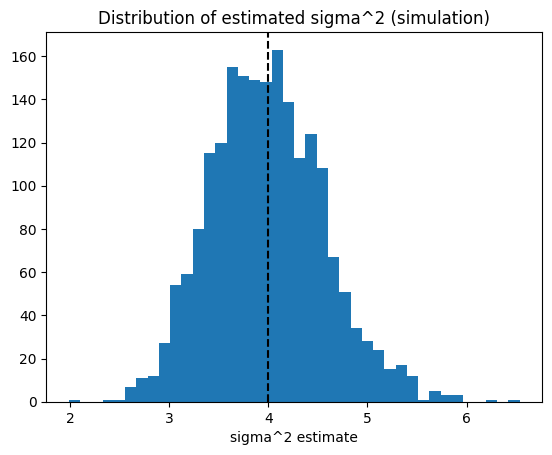

In [5]:
# Simulation to check unbiasedness empirically
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)


N = 100
p = 5
sigma_true = 2.0
num_trials = 2000


X = np.random.randn(N, p)
# ensure full column rank (usually ok for random Gaussian X)
beta_true = np.arange(1, p+1).astype(float)


estimates = []
for t in range(num_trials):
      eps = np.random.randn(N) * sigma_true
      Y = X @ beta_true + eps
      # OLS estimate
      beta_hat = np.linalg.solve(X.T @ X, X.T @ Y)
      residuals = Y - X @ beta_hat
      RSS = residuals.T @ residuals
      sigma_hat_sq = RSS / (N - p)
      estimates.append(sigma_hat_sq)


estimates = np.array(estimates)
print('True sigma^2 =', sigma_true**2)
print('Mean of estimates =', estimates.mean())
print('Std of estimates =', estimates.std())



plt.hist(estimates, bins=40)
plt.axvline(sigma_true**2, color='k', linestyle='--')
plt.title('Distribution of estimated sigma^2 (simulation)')
plt.xlabel('sigma^2 estimate')
plt.show()

# Exercise 02:

Starting from ${\rm RSS}_\Sigma(\beta) \equiv e^\top \Sigma^{-1} e$, Show that $\hat{\beta} = (X^\top \Sigma^{-1} X)^{-1} X^\top \Sigma^{-1} Y$ using the maximum liklihood estimator.

We now consider the general linear model with correlated errors:

$$
Y = X\beta + \varepsilon, \quad \varepsilon \sim N(0, \Sigma)
$$

where $\Sigma$ is a known $N \times N$ positive definite covariance matrix.

The **weighted residual sum of squares** is:

$$
\mathrm{RSS}_\Sigma(\beta) = e^\top \Sigma^{-1} e = (Y - X\beta)^\top \Sigma^{-1} (Y - X\beta)
$$

This comes directly from the Gaussian **log-likelihood**:

$$
\ell(\beta) = -\frac{1}{2}\log \det(2\pi \Sigma) - \frac{1}{2} (Y - X\beta)^\top \Sigma^{-1} (Y - X\beta)
$$

Maximizing $\ell(\beta)$ is equivalent to **minimizing $\mathrm{RSS}_\Sigma(\beta)$**.

---

### Take derivative:

Using matrix calculus:

$$
\frac{\partial}{\partial \beta} (Y - X\beta)^\top \Sigma^{-1} (Y - X\beta) = -2 X^\top \Sigma^{-1} (Y - X\beta)
$$

---

### Set gradient to zero:

$$
X^\top \Sigma^{-1} (Y - X\hat\beta) = 0
$$

---

### Solve for $\hat\beta$:

$$
X^\top \Sigma^{-1} Y - X^\top \Sigma^{-1} X \, \hat\beta = 0 \quad \implies \quad X^\top \Sigma^{-1} X \, \hat\beta = X^\top \Sigma^{-1} Y
$$

Assuming $X^\top \Sigma^{-1} X$ is invertible:

$$
\boxed{\hat\beta = (X^\top \Sigma^{-1} X)^{-1} X^\top \Sigma^{-1} Y}
$$

This is the **generalized least squares (GLS)** estimator, which is also the **maximum likelihood estimator** for $\beta$ under Gaussian errors with covariance $\Sigma$.

---

1. Weighted least squares accounts for correlated or heteroskedastic errors using $\Sigma^{-1}$.  
2. If $\Sigma = \sigma^2 I$, this reduces to ordinary least squares.  

---
## References:
1. https://en.wikipedia.org/wiki/Weighted_least_squares
2. ChatGPT for generating the formulas and check the algebra.

# Exercise 03:

Prove that provided the Boltzmann distribution the loss function is given by $L = -\frac{1}{N}\sum_{n=1}^{N} \sum_{i=1}^{c} y_{n,i} \log(\hat{y}_{n,i})$ where $y_{n,i}$ stands for the known target and $\hat{y}_{n,i}$ the estimation. $n$ runs over the data sample and $i$ shows the number of classes.

We want to derive the cross entropy loss (negative log likelihood) for a multi class classification problem assuming the Boltzmann (softmax) distribution.

First, consider a dataset with N examples and C classes. For each example n, we have:

- The true label as a one hot vector: $$y_n = (y_{n,1}, y_{n,2}, \dots, y_{n,C})$$ where $$y_{n,i} = 1$$ if class i is the correct class, otherwise 0.
- The predicted probabilities: $$\hat y_n = (\hat y_{n,1}, \dots, \hat y_{n,C})$$ given by the softmax / Boltzmann formula:
$$
\hat y_{n,i} = \frac{\exp(z_{n,i})}{\sum_{j=1}^{C} \exp(z_{n,j})}
$$
where $$z_{n,i}$$ is the score for class i.

Since we assume **independent samples**, the likelihood of observing all N labels is:
$$
\mathcal{L} = \prod_{n=1}^N P(y_n | z_n) = \prod_{n=1}^N \prod_{i=1}^C \hat y_{n,i}^{\,y_{n,i}}
$$


This works because for one hot vectors, $\prod_i \hat y_{n,i}^{y_{n,i}}$ picks exactly the probability of the true class.

Next, to estimate the model parameters we **maximize the likelihood**. It is easier to work with the **negative log likelihood**:
$$
-\log \mathcal{L} = - \sum_{n=1}^N \sum_{i=1}^C y_{n,i} \log \hat y_{n,i}
$$

Finally, we often write the **average per example loss** by dividing by N:
$$
L = - \frac{1}{N} \sum_{n=1}^N \sum_{i=1}^C y_{n,i} \log \hat y_{n,i}
$$

The negative log-likelihood under the Boltzmann/softmax model directly gives the **cross entropy loss**. Each term measures how well the model probability $\hat y_{n,i}$ matches the true label $y_{n,i}$. Minimizing this loss is equivalent to maximizing the likelihood of the observed labels.

----
P.S. I have no idea this is true or not!


# Exercise 04:

In this exercise, we will explore a two-phase workflow to understand and predict cosmological parameters from the matter power spectrum $P(k)$.

- **Phase 1**: Physics Intuition — use **CAMB** sowftware to compute $P(k)$ for different values of $\Omega_m$ and $H_0$, visualize the results, and analyze physical trends.
- **Phase 2**: Machine Learning Regression — use a pre-generated dataset of $P(k)$ curves to train a neural network and recover $\Omega_m$ and $H_0$.

---

Phase 1 – Physics Intuition with CAMB
--

In this phase, you will:

1. Compute the baseline $P(k)$ for $\Omega_m = 0.3$ and $H_0 = 70$ using **CAMB**.
2. Explore the effect of **varying $\Omega_m$** (e.g., 0.2, 0.4, 0.5) while fixing $H_0$.
3. Explore the effect of **varying $H_0$** (e.g., 65, 72, 75) while fixing $\Omega_m$.
4. Compare curves on log–log plots and discuss:
   - How the amplitude changes.
   - How the scale of the turnover in $P(k)$ shifts.
5. Relate your findings to physical interpretations (e.g., matter–radiation equality scale, growth suppression).
---


Phase 2 – Machine Learning Regression
--

In this exercise, you will develop, train, and evaluate a machine learning model to estimate two cosmological parameters — the matter density parameter $\Omega_m$ and the Hubble constant $H_0$ — from the matter power spectrum $P(k)$.

The training and testing datasets you will receive were generated using the **CAMB** cosmology code, varying $\Omega_m$ and $H_0$ within a certain range.  
Each sample consists of:

- A set of $P(k)$ values at predefined $k$-values (wavenumbers in $h/\mathrm{Mpc}$) at redshift $z = 0$.  
- The true value of cosmological parameters including $\Omega_m$ and $H_0$.

---

**Your tasks:**

1. **Load** the dataset from the provided npz format file (`./data/pk_dataset.npz`).
2. **Split** the data into training and testing subsets with ratio 90/10.
3. **Build and train** a machine learning regressor to predict $\Omega_m$ and $H_0$ from the \(P(k)\) array.
4. **Plot** predicted vs. true values for both $\Omega_m$ and $H_0$ across the test subset.
---

In [1]:
import numpy as np
import camb
import matplotlib.pyplot as plt


# Load datasets

params = np.load('/home/nazanin/Data/params.npy')  # (200,2) [Ωm, H0] for each model
params.shape
PK_data = np.load('/home/nazanin/Data/Pk.npy')     # (200,200)  precomputed P(k) for each model
PK_data.shape
K = np.load('/home/nazanin/Data/k.npy')     # (200,200)  k values corresponding to each P(k)
K.shape

# Function to compute P(k) for a given Ωm and H0

def compute_pk(Omega_m, H0, k_array):
    
     """
    Compute the matter power spectrum P(k) at redshift z=0 for a given 
    total matter density Omega_m and Hubble constant H0.

    Inputs:
    - Omega_m : total matter density parameter
    - H0      : Hubble parameter in km/s/Mpc
    - k_array : array of wavenumbers [h/Mpc] to compute P(k) at

    Output:
    - pk_interp: P(k) interpolated at the provided k_array
    """
        
    #H_0 --> km/s/Mpc

    h = H0 / 100.0    # CAMB uses h in cosmology parameters (dimensionless)

    # ------------------------------
    # Split total matter into baryons and cold dark matter
    # ------------------------------

    Omega_b = 0.0486              # baryon density fraction (fixed)
    Omega_c = Omega_m - Omega_b   # cold dark matter fraction

    # CAMB expects physical densities: Ω_b h^2 and Ω_c h^2
    
    ombh2 = Omega_b * h**2
    omch2 = Omega_c * h**2
    
    # ------------------------------
    # Set up CAMB parameters
    # ------------------------------

    pars = camb.CAMBparams()                                       # initialize CAMB parameter object
    pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2)
    pars.InitPower.set_params(ns=0.965, As=2.1e-9)                 # initial power spectrum: spectral index ns, amplitude As
    pars.set_matter_power(redshifts=[0], kmax=k_array.max()*1.2)   # compute P(k) at z=0, up to slightly beyond max k
 

    # ------------------------------
    # Get CAMB results
    # ------------------------------
    
    
    results = camb.get_results(pars)                                # run CAMB
    kh, z, pk = results.get_matter_power_spectrum(
        minkh=k_array.min()/1.2,                                    # min k slightly below the lowest k in array
        maxkh=k_array.max()*1.2,                                    # max k slightly above the largest k
        npoints=len(k_array)+50                                     # compute extra points for smooth interpolation
    )

    # ------------------------------
    # Interpolate CAMB output to our exact k_array
    # ------------------------------
    from scipy.interpolate import interp1d
    f = interp1d(kh, pk[0], kind='cubic')                           # cubic spline interpolation
    return f(k_array)



In [2]:
# ------------------------------
# Compute P(k) for ALL 200 models
# ------------------------------
PK_camb = np.zeros_like(PK_data)

for i, (Omega_m, H0) in enumerate(params):
    PK_camb[i] = compute_pk(Omega_m, H0, K)

# Save for comparison
np.save('PK_camb.npy', PK_camb)
print("Computed CAMB P(k) for all models.")


Computed CAMB P(k) for all models.


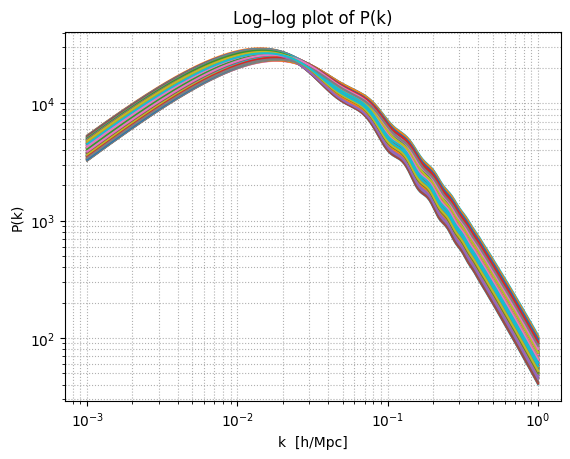

In [20]:
for i in range(PK_camb.shape[0]):
    plt.loglog(K, PK_camb[i])

plt.xlabel("k  [h/Mpc]")
plt.ylabel("P(k)")
plt.title("Log–log plot of P(k)")
plt.grid(True, which='both', ls=':')
plt.show()


## 2. Explore the effect of **varying $\Omega_m$** (e.g., 0.2, 0.4, 0.5) while fixing $H_0$:

### Compare curves on log–log plots and discuss:
   - How the amplitude changes.
   - How the scale of the turnover in $P(k)$ shifts.

#### At large scales (small k):

Increasing $\Omega_m$ raises the total matter content, This slightly increases the amplitude of fluctuations on large scales.

#### At intermediate + small scales (larger k)

Higher $\Omega_m$  boosts structure formation in later time and closer to our world.


In my plot red curve (Ωm=0.5) is higher than green (0.4), orange (0.3), and blue (0.2) at small and intermediate k. That is exactly expected.

-----------------------------------------------------------------------------------------------

The turnover in $P(k)$ corresponds to modes that entered the horizon at the
epoch of matter–radiation equality.  
The characteristic wavenumber of this turnover is approximately:

$
k_{\rm eq} \propto \Omega_m h^2 $

where $h = H_0 / 100$ is the reduced Hubble parameter.

If $\Omega_m$ increases, K increases.


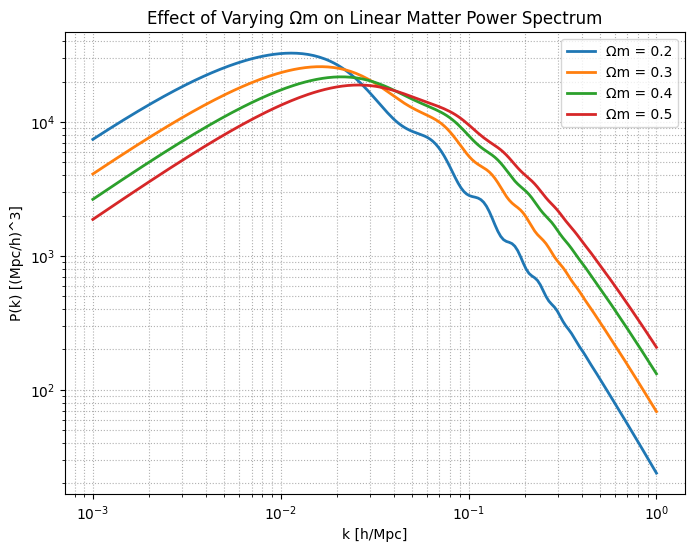

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import camb
from camb import model

# Fixed Hubble parameter
H0 = 70.0  # km/s/Mpc
h = H0 / 100.0

# Ωm values to explore
Omega_m_values = [0.2, 0.3, 0.4, 0.5]

# Fixed baryon density and spectral parameters
Omega_b = 0.0486
ns = 0.965
As = 2.1e-9

# k-array for P(k) evaluation (h/Mpc)
K = np.logspace(-3, 0, 200)  # 0.001 to 1 h/Mpc

def compute_pk(Omega_m, H0, k_array):
    h = H0 / 100.0
    Omega_c = Omega_m - Omega_b
    ombh2 = Omega_b * h**2
    omch2 = Omega_c * h**2

    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2)
    pars.InitPower.set_params(ns=ns, As=As)
    pars.set_matter_power(redshifts=[0], kmax=k_array.max()*1.2)

    results = camb.get_results(pars)
    kh, z, pk = results.get_matter_power_spectrum(
        minkh=k_array.min()/1.2,
        maxkh=k_array.max()*1.2,
        npoints=len(k_array)+50
    )

    # Interpolate to the exact k-array
    from scipy.interpolate import interp1d
    f = interp1d(kh, pk[0], kind='cubic')
    return f(k_array)
PK_list = []
for Omega_m in Omega_m_values:
    PK_list.append(compute_pk(Omega_m, H0, K))


plt.figure(figsize=(8,6))

for Omega_m, Pk in zip(Omega_m_values, PK_list):
    plt.loglog(K, Pk, linewidth=2, label=f'Ωm = {Omega_m}')

plt.xlabel("k [h/Mpc]")
plt.ylabel("P(k) [(Mpc/h)^3]")
plt.title("Effect of Varying Ωm on Linear Matter Power Spectrum")
plt.legend()
plt.grid(True, which='both', ls=':')
plt.show()


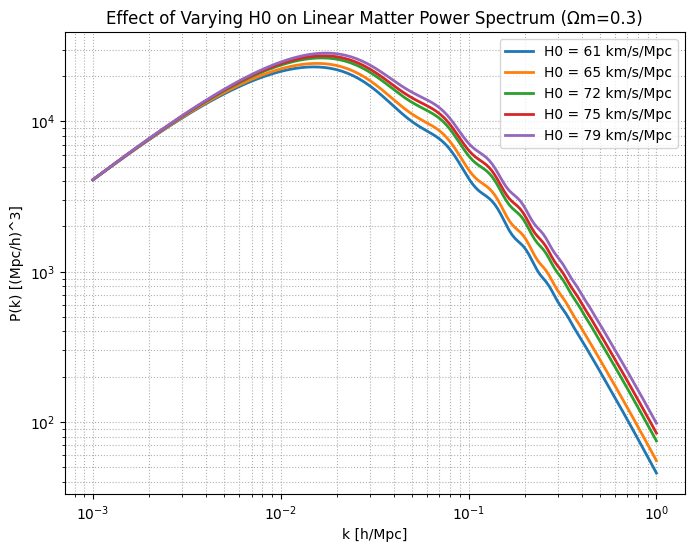

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import camb
from camb import model

# Fixed Ωm
Omega_m = 0.3

# H0 values to explore
H0_values = [61, 65, 72, 75,79]

# Fixed baryon density and spectral parameters
Omega_b = 0.0486
ns = 0.965
As = 2.1e-9

# k-array for P(k) evaluation (h/Mpc)
K = np.logspace(-3, 0, 200)

def compute_pk(Omega_m, H0, k_array):
    h = H0 / 100.0
    Omega_c = Omega_m - Omega_b
    ombh2 = Omega_b * h**2
    omch2 = Omega_c * h**2

    pars = camb.CAMBparams()
    # Correct cosmology call
    pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2)
    pars.InitPower.set_params(ns=ns, As=As)
    pars.set_matter_power(redshifts=[0], kmax=k_array.max()*1.2)

    results = camb.get_results(pars)
    kh, z, pk = results.get_matter_power_spectrum(
        minkh=k_array.min()/1.2,
        maxkh=k_array.max()*1.2,
        npoints=len(k_array)+50
    )

    # Interpolate to exact k-array
    from scipy.interpolate import interp1d
    f = interp1d(kh, pk[0], kind='cubic')
    return f(k_array)

# Compute P(k) for all H0 values
PK_list = []
for H0 in H0_values:
    PK_list.append(compute_pk(Omega_m, H0, K))

# Plot
plt.figure(figsize=(8,6))
for H0, Pk in zip(H0_values, PK_list):
    plt.loglog(K, Pk, linewidth=2, label=f'H0 = {H0} km/s/Mpc')

plt.xlabel("k [h/Mpc]")
plt.ylabel("P(k) [(Mpc/h)^3]")
plt.title(f"Effect of Varying H0 on Linear Matter Power Spectrum (Ωm={Omega_m})")
plt.legend()
plt.grid(True, which='both', ls=':')
plt.show()


### Relate your findings to physical interpretations (e.g., matter–radiation equality scale, growth suppression)


**The turnover (the peak) in the matter power spectrum occurs around the horizon size at matter–radiation equality.**

When $\Omega_m$increases:

The universe becomes matter-dominated earlier and equality happens at a higher redshift.The horizon size at equality is smaller. Therefore, the corresponding wave number
the corresponding wave number $k_{eq}$
 is larger. This shifts the turnover to larger k (to the right)

-------------------------------------------------------



Phase 2 – Machine Learning Regression
--

In this exercise, you will develop, train, and evaluate a machine learning model to estimate two cosmological parameters — the matter density parameter $\Omega_m$ and the Hubble constant $H_0$ — from the matter power spectrum $P(k)$.

The training and testing datasets you will receive were generated using the **CAMB** cosmology code, varying $\Omega_m$ and $H_0$ within a certain range.  
Each sample consists of:

- A set of $P(k)$ values at predefined $k$-values (wavenumbers in $h/\mathrm{Mpc}$) at redshift $z = 0$.  
- The true value of cosmological parameters including $\Omega_m$ and $H_0$.

---

**Your tasks:**

1. **Load** the dataset from the provided npz format file (`./data/pk_dataset.npz`).
2. **Split** the data into training and testing subsets with ratio 90/10.
3. **Build and train** a machine learning regressor to predict $\Omega_m$ and $H_0$ from the \(P(k)\) array.
4. **Plot** predicted vs. true values for both $\Omega_m$ and $H_0$ across the test subset.
---

In [7]:
pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 123.5 kB/s eta 0:00:00m eta 0:00:010:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.4/308.4 kB 97.9 kB/s eta 0:00:00m eta 0:00:010:01:01
Note: you may need to restart the kernel to use updated packages.


In [15]:
#1. Compute the baseline $P(k)$ for $\Omega_m = 0.3$ and $H_0 = 70$ using **CAMB**.

import numpy as np, os
import matplotlib.pyplot as plt

import os, glob
import numpy as np
import camb
import matplotlib.pyplot as plt



In [16]:
# Load datasets

params = np.load('/home/nazanin/Data/params.npy')  # (200,2) [Ωm, H0]
params.shape
PK_data = np.load('/home/nazanin/Data/Pk.npy')     # (200,200)
PK_data.shape
K = np.load('/home/nazanin/Data/k.npy')
K.shape

(200,)

In [17]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt


# Features and labels
X = PK_data
y = params   # columns: Ωm , H0

# ---------------------------------------------------------
# 2. TRAIN–TEST SPLIT  (90/10)
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42)

# Optionally standardize P(k)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train.shape,X_test.shape)
print(y_train.shape, y_test.shape)

(180, 200) (20, 200)
(180, 2) (20, 2)


In machine learning we often encounter regression, these problems involve predicting a continuous target variable, such as house prices, or temperature. However, in many real-world scenarios, we need to predict not only single but many variables together, this is where we use multi-output regression. We know in simple regression we predict a single output variable but where the goal is to predict multiple target variables instead of just one we use Multi-output regression.

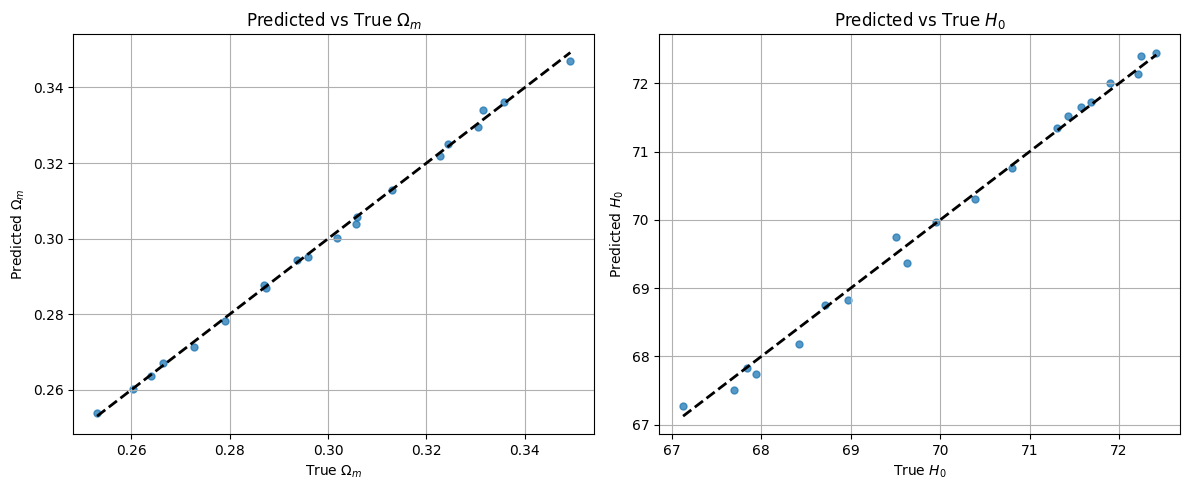

In [18]:
# BUILD + TRAIN "Random Forest Regressor"

model = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        random_state=42
    )
)


model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)


# PLOT PREDICTED vs TRUE FOR BOTH Ωm and H0


labels = [r"$\Omega_m$", r"$H_0$"]

plt.figure(figsize=(12,5))

for i in range(2):
    plt.subplot(1,2,i+1)
    plt.scatter(y_test[:,i], y_pred[:,i], s=25, alpha=0.75)
    plt.plot([y_test[:,i].min(), y_test[:,i].max()],
             [y_test[:,i].min(), y_test[:,i].max()],
             "k--", linewidth=2)
    plt.xlabel(f"True {labels[i]}")
    plt.ylabel(f"Predicted {labels[i]}")
    plt.title(f"Predicted vs True {labels[i]}")
    plt.grid(True)

plt.tight_layout()
plt.show()


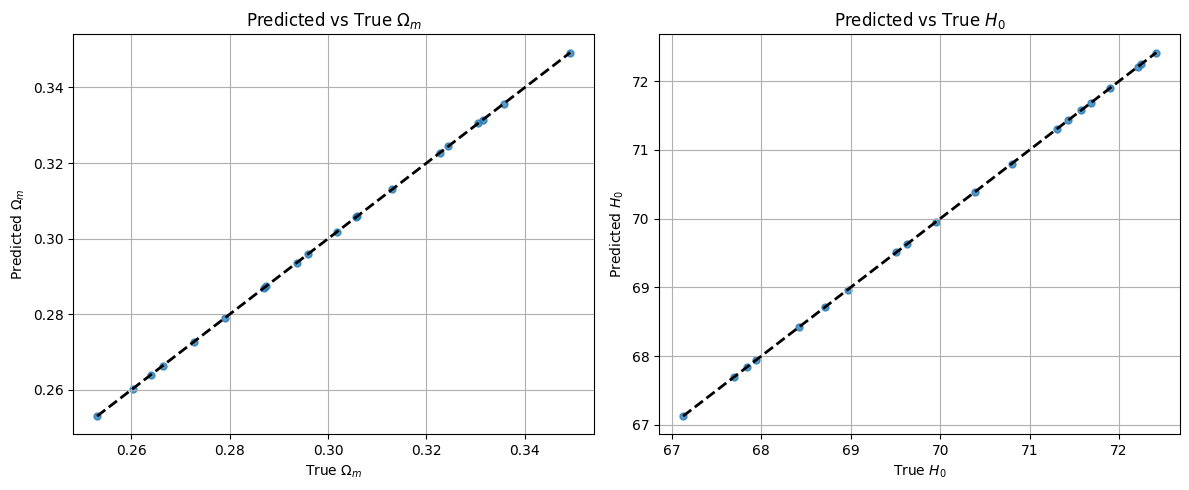

In [19]:
# BUILD + TRAIN "Linear REGRESSOR"

from sklearn.linear_model import LinearRegression

model = LinearRegression()



model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)


# PLOT PREDICTED vs TRUE FOR BOTH Ωm and H0

labels = [r"$\Omega_m$", r"$H_0$"]

plt.figure(figsize=(12,5))

for i in range(2):
    plt.subplot(1,2,i+1)
    plt.scatter(y_test[:,i], y_pred[:,i], s=25, alpha=0.75)
    plt.plot([y_test[:,i].min(), y_test[:,i].max()],
             [y_test[:,i].min(), y_test[:,i].max()],
             "k--", linewidth=2)
    plt.xlabel(f"True {labels[i]}")
    plt.ylabel(f"Predicted {labels[i]}")
    plt.title(f"Predicted vs True {labels[i]}")
    plt.grid(True)

plt.tight_layout()
plt.show()


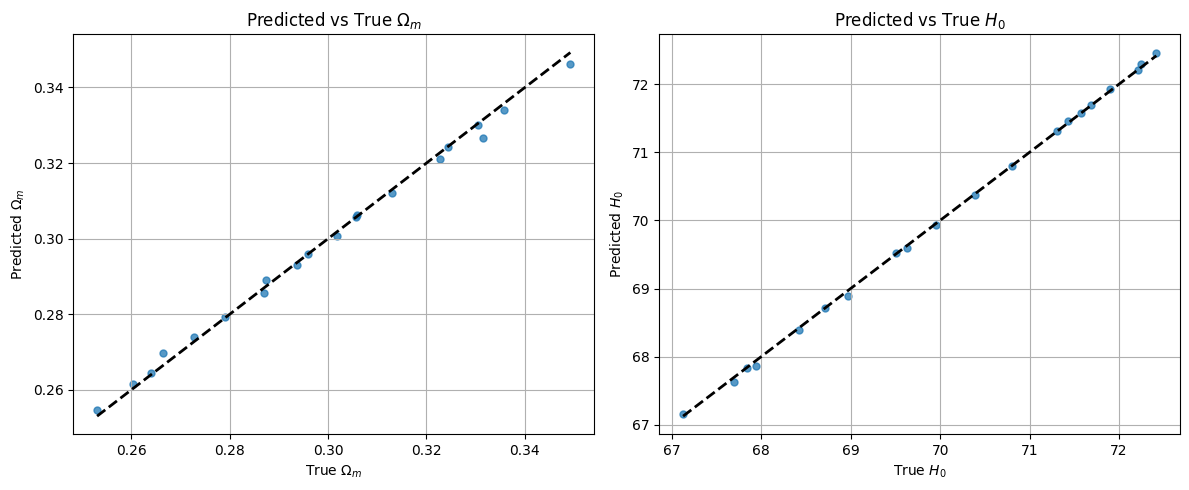

In [21]:

# BUILD + TRAIN "ExtraTrees REGRESSOR"

from sklearn.ensemble import ExtraTreesRegressor
extra_reg = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

extra_reg.fit(X_train_scaled, y_train)


#  MAKE PREDICTIONS


y_pred = extra_reg.predict(X_test_scaled)



# PLOT PREDICTED vs TRUE FOR BOTH Ωm and H0


labels = [r"$\Omega_m$", r"$H_0$"]

plt.figure(figsize=(12,5))

for i in range(2):
    plt.subplot(1,2,i+1)
    plt.scatter(y_test[:,i], y_pred[:,i], s=25, alpha=0.75)
    plt.plot([y_test[:,i].min(), y_test[:,i].max()],
             [y_test[:,i].min(), y_test[:,i].max()],
             "k--", linewidth=2)
    plt.xlabel(f"True {labels[i]}")
    plt.ylabel(f"Predicted {labels[i]}")
    plt.title(f"Predicted vs True {labels[i]}")
    plt.grid(True)

plt.tight_layout()
plt.show()


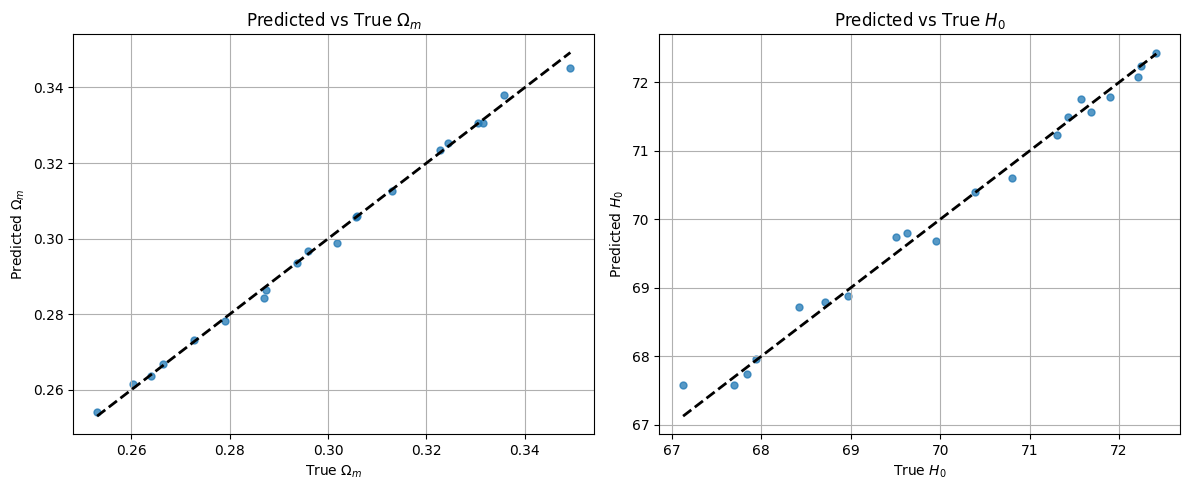

In [22]:
#  BUILD + TRAIN KNeighborsRegressor REGRESSOR

from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(
    n_neighbors=5,      # default is 5 — you can tune this
    weights='distance'  # (optional) helps when samples vary strongly
)
knn.fit(X_train_scaled,y_train)
# Make predictions
y_pred = knn.predict(X_test_scaled)


# PLOT PREDICTED vs TRUE FOR BOTH Ωm and H0


labels = [r"$\Omega_m$", r"$H_0$"]

plt.figure(figsize=(12,5))

for i in range(2):
    plt.subplot(1,2,i+1)
    plt.scatter(y_test[:,i], y_pred[:,i], s=25, alpha=0.75)
    plt.plot([y_test[:,i].min(), y_test[:,i].max()],
             [y_test[:,i].min(), y_test[:,i].max()],
             "k--", linewidth=2)
    plt.xlabel(f"True {labels[i]}")
    plt.ylabel(f"Predicted {labels[i]}")
    plt.title(f"Predicted vs True {labels[i]}")
    plt.grid(True)

plt.tight_layout()
plt.show()


### Summary of Findings

In this phase, four different regression models were trained to predict the cosmological parameters $ \Omega_m

 and $H_0$
 from the matter power spectrum p(k).

The tested models were:

1.Random Forest Regressor

2.Linear Regression

3.Extra Trees Regressor

4.K-Neighbors Regressor

The evaluation was based on Predicted vs. True scatter plots, where a perfect model places all points on the 45-degree line.


##### Linear Regression
Surprisingly, Linear Regression produced almost perfect predictions!!, with points lying very close to the 45-degree line.
This behavior is unexpected because the relationship between
P(k) and cosmological parameters is normally nonlinear.
The result suggests that the dataset may be too simple, nearly linear, or that the parameter ranges are narrow, allowing even a linear model to perform extremely well.

##### Random Forest and Extra Trees
These models also performed well and captured some nonlinear relationships in the data.
They are generally more robust for realistic cosmological inference.

##### KNN Regressor
This model performed worse than the others, likely because nearest-neighbor methods are sensitive to noise and do not scale well in high dimensions (200-dimensional
P(k)).
